# 12 — Terrain Transition Detection Analysis

## Motivation

Standard classification metrics (accuracy, macro-F1) treat every window equally, but for a mobile robot the *timing* of terrain changes matters. If the robot is crossing from grass to a muddy dirt track, a model that detects the new terrain two seconds after the change allows the controller to adapt early enough; one that takes ten seconds (or never detects it) could cause wheel slip or path deviation.

This notebook measures **transition detection latency**: how many seconds after a ground-truth terrain change does each model first produce a stable classification of the new class?

## Setup

- **Data**: `dataset_A_pruned_5run.csv` — windowed features (2-second windows, 1-second step, 5 runs).
- **Raw windows**: `raw_windows_cnn.parquet` — raw IMU signal windows for the CNN.
- **Models**: RandomForest, XGBoost, LogisticRegression, SVM (classical) + MLP + CNN (deep learning).
- **Evaluation**: LORO-CV — predictions generated fresh, per fold, to avoid data leakage.

## Stability Criterion

A 'detected' transition requires `N_STABLE` consecutive windows all predicting the new class.  At a 1-second window step, `N_STABLE=3` means a 3-second confirmation window.  This prevents noisy single-window misclassifications from counting as genuine detections.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Project root bootstrap
# ---------------------------------------------------------------------------
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.transition import (
    # Prediction generation
    run_classical_loro_cv,
    run_mlp_loro_cv,
    run_cnn_loro_cv,
    # Analysis
    detect_gt_transitions,
    analyze_transitions,
    compare_models,
    # Visualization
    plot_transition_timeline,
    plot_detection_delay_histogram,
    # Constants
    LABEL_ORDER,
    TERRAIN_COLORS,
    ID_COLS,
)

# ---------------------------------------------------------------------------
# Global style
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DATA_DIR    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Experiment parameters  (adjust these to reproduce different settings)
# ---------------------------------------------------------------------------
RANDOM_STATE    = 42
N_STABLE        = 3      # consecutive windows required for a stable detection
THRESHOLD_SEC   = 10.0   # delays > this are flagged 'late'

LABEL_COL = "label"
RUN_COL   = "run_id"

print("Setup complete.")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  N_STABLE     : {N_STABLE} windows")
print(f"  THRESHOLD    : {THRESHOLD_SEC} s")

Setup complete.
  Project root : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
  N_STABLE     : 3 windows
  THRESHOLD    : 10.0 s


## 1. Load Data

In [2]:
# ---------------------------------------------------------------------------
# Feature dataset (classical models + MLP)
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_DIR / "dataset_A_pruned_5run.csv")
feature_cols = [c for c in df.columns if c not in ID_COLS]
run_ids = sorted(df[RUN_COL].unique().tolist())

print(f"Feature dataset : {len(df)} windows, {len(feature_cols)} features, {len(run_ids)} runs")
print(f"Runs            : {run_ids}")
print(f"Label counts    :")
print(df[LABEL_COL].value_counts().to_string())
print()

# ---------------------------------------------------------------------------
# Raw-window dataset (CNN only)
# ---------------------------------------------------------------------------
cnn_parquet = DATA_DIR / "raw_windows_cnn.parquet"
cnn_df = pd.read_parquet(cnn_parquet)
print(f"CNN raw windows : {len(cnn_df)} windows")
series_cols = [c for c in cnn_df.columns if c.endswith("__series")]
print(f"Series columns  : {series_cols}")

Feature dataset : 2346 windows, 123 features, 5 runs
Runs            : ['log_20260223_142511.490', 'log_20260226_102148.990', 'log_20260309_141435.414_partA', 'log_20260309_141435.414_partB', 'log_20260326_120021.508']
Label counts    :
label
smooth_terrain      706
dry_dirt_track      652
grass               488
cobblestone         355
muddy_dirt_track    145

CNN raw windows : 2346 windows
Series columns  : ['ax__series', 'ay__series', 'az__series', 'gx__series', 'gz__series']


## 2. Ground-Truth Transition Inventory

Before any model is involved, we identify all terrain label changes in the dataset. Each transition is a pair `(from_label → to_label)` with an associated timestamp.

In [3]:
gt_transition_rows = []

for run_id in run_ids:
    run_df = (
        df[df[RUN_COL] == run_id]
        .sort_values("t_start")
        .rename(columns={"t_start": "time", LABEL_COL: "true_label"})
        .reset_index(drop=True)
    )
    transitions = detect_gt_transitions(run_df, time_col="time", true_col="true_label")
    for t in transitions:
        t["run_id"] = run_id
    gt_transition_rows.extend(transitions)

gt_df = pd.DataFrame(gt_transition_rows)[["run_id", "from_label", "to_label", "gt_time"]]

print(f"Total ground-truth transitions across all runs: {len(gt_df)}")
print()
print(gt_df.to_string(index=False))

Total ground-truth transitions across all runs: 12

                       run_id     from_label         to_label  gt_time
      log_20260223_142511.490          grass   smooth_terrain   511.19
      log_20260223_142511.490 smooth_terrain muddy_dirt_track   711.74
      log_20260226_102148.990          grass   smooth_terrain   642.58
      log_20260226_102148.990 smooth_terrain muddy_dirt_track   982.29
log_20260309_141435.414_partA          grass   smooth_terrain   414.06
log_20260309_141435.414_partA smooth_terrain   dry_dirt_track   649.28
log_20260309_141435.414_partB dry_dirt_track            grass  1852.06
log_20260309_141435.414_partB          grass   smooth_terrain  2392.06
log_20260309_141435.414_partB smooth_terrain      cobblestone  2461.74
log_20260309_141435.414_partB    cobblestone   smooth_terrain  2627.06
      log_20260326_120021.508          grass   smooth_terrain   533.10
      log_20260326_120021.508 smooth_terrain      cobblestone  1147.39


## 3. Generate Per-Window Predictions (LORO-CV)

All six models are evaluated via **Leave-One-Run-Out cross-validation**.  For each test run, the model is trained on the remaining runs and used to predict every window in the test run.  This produces a per-window `pred_label` column for each model without data leakage.

**Note:** The MLP and CNN require full retraining per fold — expect ~2–5 minutes each.

In [4]:
# ---------------------------------------------------------------------------
# Classical models
# ---------------------------------------------------------------------------
CLASSICAL_MODELS = ["RandomForest", "XGBoost", "LogisticRegression", "SVM"]

predictions: dict[str, pd.Series] = {}

for model_name in CLASSICAL_MODELS:
    print(f"Running LORO-CV for {model_name}...")
    df_pred = run_classical_loro_cv(
        df=df,
        feature_cols=feature_cols,
        label_col=LABEL_COL,
        run_col=RUN_COL,
        model_name=model_name,
        imbalance="balanced",
        random_state=RANDOM_STATE,
    )
    predictions[model_name] = df_pred["pred_label"]
    acc = (predictions[model_name] == df[LABEL_COL]).mean()
    print(f"  {model_name}: overall LORO-CV accuracy = {acc:.3f}")

print("\nClassical models done.")

Running LORO-CV for RandomForest...
  RandomForest: overall LORO-CV accuracy = 0.733
Running LORO-CV for XGBoost...
  XGBoost: overall LORO-CV accuracy = 0.740
Running LORO-CV for LogisticRegression...
  LogisticRegression: overall LORO-CV accuracy = 0.743
Running LORO-CV for SVM...
  SVM: overall LORO-CV accuracy = 0.715

Classical models done.


In [5]:
# ---------------------------------------------------------------------------
# MLP  (~1–3 min)
# ---------------------------------------------------------------------------
print("Running LORO-CV for MLP (this may take a few minutes)...")
df_mlp = run_mlp_loro_cv(
    df=df,
    feature_cols=feature_cols,
    label_col=LABEL_COL,
    run_col=RUN_COL,
    hidden_dims=[256, 128, 64],
    dropout_rate=0.3,
    batch_size=32,
    max_epochs=200,
    patience=20,
    learning_rate=1e-3,
    weight_decay=1e-4,
    random_state=RANDOM_STATE,
)
predictions["MLP"] = df_mlp["pred_label"]
acc = (predictions["MLP"] == df[LABEL_COL]).mean()
print(f"  MLP: overall LORO-CV accuracy = {acc:.3f}")

Running LORO-CV for MLP (this may take a few minutes)...
  MLP fold log_20260223_142511.490: acc=0.672
  MLP fold log_20260226_102148.990: acc=0.855
  MLP fold log_20260309_141435.414_partA: acc=0.858
  MLP fold log_20260309_141435.414_partB: acc=0.881
  MLP fold log_20260326_120021.508: acc=0.455
  MLP: overall LORO-CV accuracy = 0.742


In [6]:
# ---------------------------------------------------------------------------
# CNN  (~3–8 min depending on hardware)
# ---------------------------------------------------------------------------
print("Running LORO-CV for CNN (this may take several minutes)...")
df_cnn = run_cnn_loro_cv(
    feature_df=df,
    cnn_df=cnn_df,
    label_col=LABEL_COL,
    run_col=RUN_COL,
    filters=[32, 64, 128],
    kernels=[7, 5, 3],
    dropout_rate=0.3,
    batch_size=32,
    max_epochs=100,
    patience=15,
    learning_rate=1e-3,
    weight_decay=1e-4,
    random_state=RANDOM_STATE,
)
predictions["CNN"] = df_cnn["pred_label"]
acc = (predictions["CNN"] == df[LABEL_COL]).mean()
print(f"  CNN: overall LORO-CV accuracy = {acc:.3f}")

Running LORO-CV for CNN (this may take several minutes)...
  CNN fold log_20260223_142511.490: acc=0.621
  CNN fold log_20260226_102148.990: acc=0.890
  CNN fold log_20260309_141435.414_partA: acc=0.920
  CNN fold log_20260309_141435.414_partB: acc=0.846
  CNN fold log_20260326_120021.508: acc=0.447
  CNN: overall LORO-CV accuracy = 0.743


## 4. Transition Analysis

For each model, we identify when it first produces `N_STABLE` consecutive correct predictions of the new terrain class after each ground-truth transition.

In [7]:
combined_transitions = compare_models(
    df=df,
    predictions_dict=predictions,
    time_col="t_start",
    true_col=LABEL_COL,
    run_col=RUN_COL,
    n_stable=N_STABLE,
    threshold_sec=THRESHOLD_SEC,
)

print(f"Total transition records: {len(combined_transitions)}")
print(f"  (= {len(gt_df)} GT transitions × {len(predictions)} models)")
print()

model_names = list(predictions.keys())
print(f"{'Model':<22}  {'Detected':>8}  {'Missed':>6}  {'Boundary':>8}  {'Det. Rate':>10}  {'Mean Delay':>10}  {'Median Delay':>12}")
print("-" * 80)
for model_name in model_names:
    sub = combined_transitions[combined_transitions["model"] == model_name]
    det   = sub[sub["outcome"] == "detected"]
    miss  = sub[sub["outcome"] == "missed"]
    bnd   = sub[sub["outcome"] == "boundary"]
    eff   = len(sub) - len(bnd)
    rate  = len(det) / eff if eff > 0 else float("nan")
    mean_d  = det["detection_delay_sec"].mean()
    med_d   = det["detection_delay_sec"].median()
    print(f"{model_name:<22}  {len(det):>8}  {len(miss):>6}  {len(bnd):>8}  "
          f"{rate:>10.1%}  {mean_d:>10.2f}s  {med_d:>12.2f}s")

Total transition records: 72
  (= 12 GT transitions × 6 models)

Model                   Detected  Missed  Boundary   Det. Rate  Mean Delay  Median Delay
--------------------------------------------------------------------------------
RandomForest                  11       1         0       91.7%       49.99s          0.00s
XGBoost                       12       0         0      100.0%       47.27s          0.50s
LogisticRegression            11       1         0       91.7%       51.67s          0.00s
SVM                            9       3         0       75.0%        0.45s          0.00s
MLP                           12       0         0      100.0%        2.79s          0.00s
CNN                           12       0         0      100.0%       48.07s          0.00s


In [9]:
# ---------------------------------------------------------------------------
# Full transition table
# ---------------------------------------------------------------------------
display_cols = [
    "model", "run_id", "from_label", "to_label",
    "gt_time", "detection_delay_sec", "outcome", "is_late",
]

styled = (
    combined_transitions[display_cols]
    .sort_values(["run_id", "gt_time", "model"])
    .style
    .format({"gt_time": "{:.1f}", "detection_delay_sec": "{:.2f}"})
    .map(
        lambda v: "background-color: #ffe0e0" if v == "missed"
        else ("background-color: #fff3cd" if v == "boundary" else ""),
        subset=["outcome"],
    )
)

styled

,model,run_id,from_label,to_label,gt_time,detection_delay_sec,outcome,is_late
60,CNN,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
24,LogisticRegression,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
48,MLP,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
0,RandomForest,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
36,SVM,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
12,XGBoost,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
61,CNN,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,0.00,detected,False
25,LogisticRegression,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,nan,missed,False
49,MLP,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,4.03,detected,False
1,RandomForest,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,1.01,detected,False


## 5. Visualizations

### 5.1 Timeline Plots

Ground-truth (top band) vs predicted (bottom band) terrain label over time for each run, using RandomForest predictions.  
- **Dashed black lines**: ground-truth transitions.  
- **Solid green lines**: stable detections (on time).  
- **Solid orange lines**: late detections (> threshold).  
- **Dotted red lines**: missed transitions.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_timelines_randomforest.png


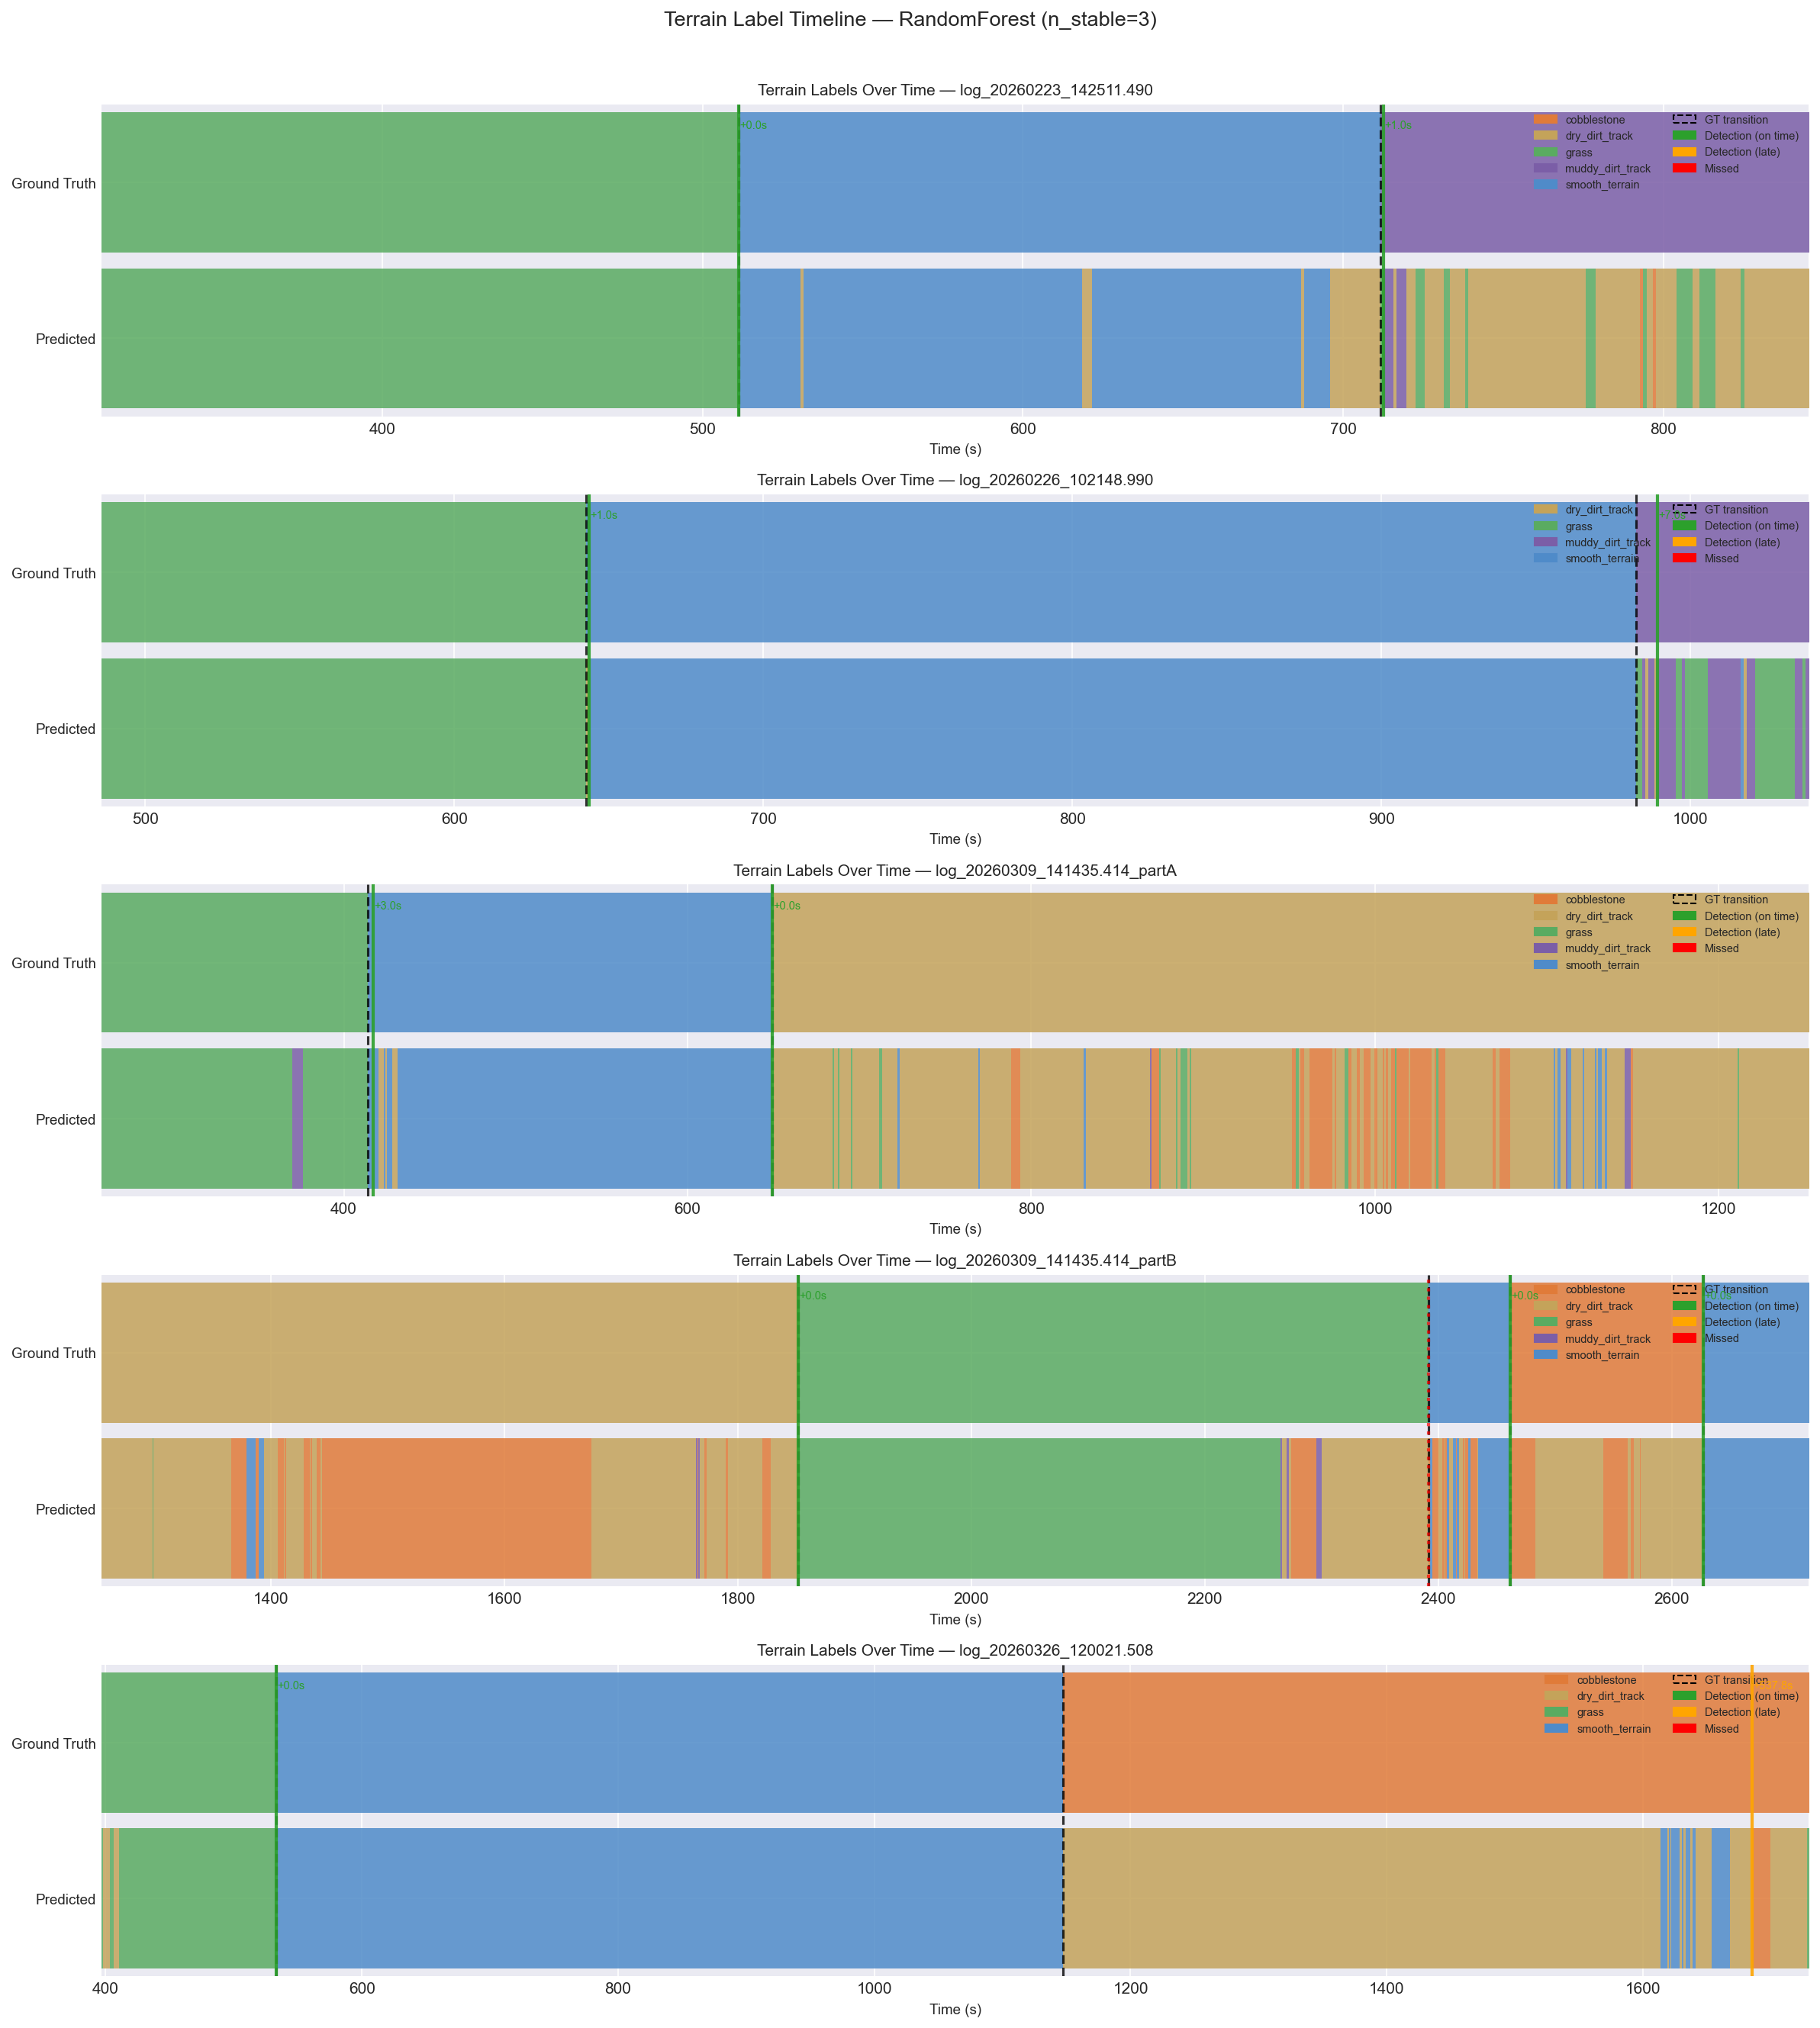

In [10]:
TIMELINE_MODEL = "RandomForest"  # change to any model in predictions

fig, axes = plt.subplots(
    len(run_ids), 1,
    figsize=(16, 3.5 * len(run_ids)),
    dpi=150,
)
if len(run_ids) == 1:
    axes = [axes]

for ax, run_id in zip(axes, run_ids):
    run_mask = df[RUN_COL] == run_id
    run_df = (
        df.loc[run_mask]
        .sort_values("t_start")
        .assign(
            time=lambda x: x["t_start"],
            true_label=lambda x: x[LABEL_COL],
            pred_label=predictions[TIMELINE_MODEL].loc[run_mask].values,
        )
        .reset_index(drop=True)
    )
    run_transitions = combined_transitions[
        (combined_transitions["run_id"] == run_id) &
        (combined_transitions["model"] == TIMELINE_MODEL)
    ]
    plot_transition_timeline(
        df=run_df,
        transitions_df=run_transitions,
        run_id=run_id,
        ax=ax,
        label_colors=TERRAIN_COLORS,
    )

fig.suptitle(
    f"Terrain Label Timeline — {TIMELINE_MODEL} (n_stable={N_STABLE})",
    fontsize=13, y=1.01,
)
fig.tight_layout()
save_path = REPORTS_DIR / f"transition_timelines_{TIMELINE_MODEL.lower()}.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

### 5.2 Detection Delay Distributions

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_delay_histograms.png


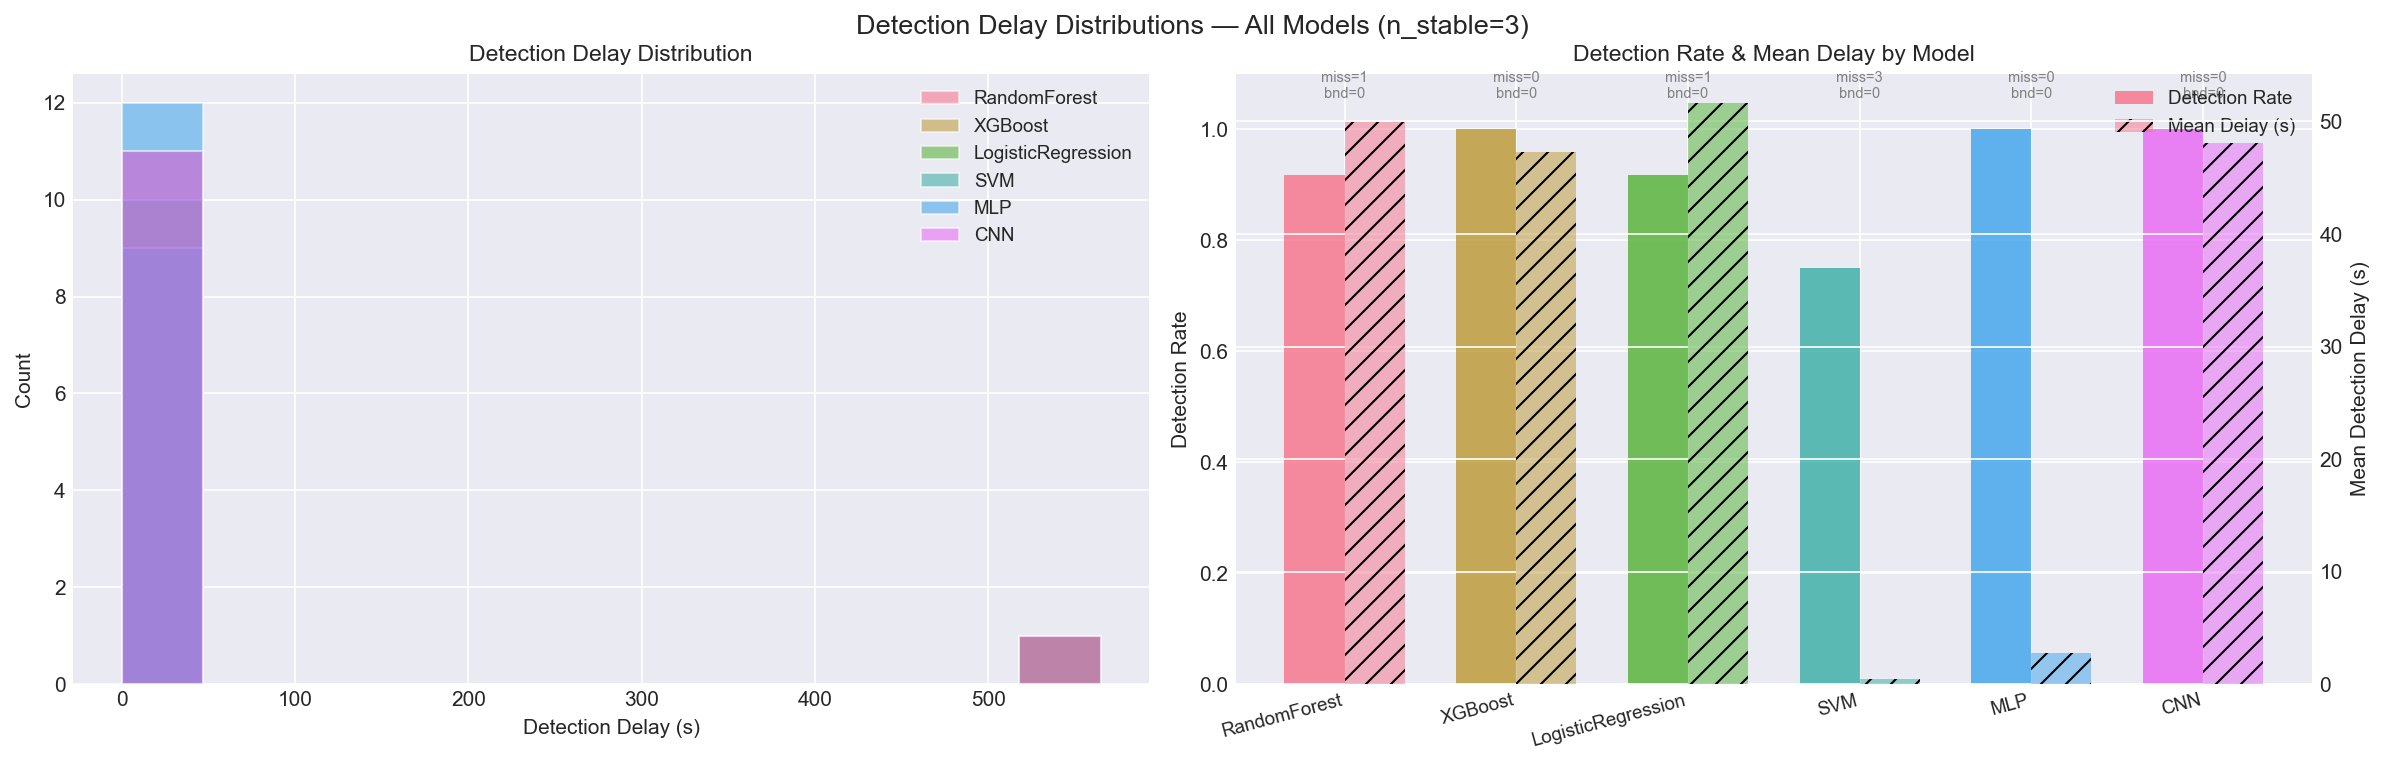

In [11]:
fig = plot_detection_delay_histogram(
    transitions_df=combined_transitions,
    bins=12,
    figsize=(16, 5),
)
fig.suptitle(
    f"Detection Delay Distributions — All Models (n_stable={N_STABLE})",
    fontsize=13, y=1.01,
)
save_path = REPORTS_DIR / "transition_delay_histograms.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

## 6. Sensitivity Analysis — Effect of `n_stable`

Higher `n_stable` values require the model to commit to the new class for longer before we count a detection.  This trades fewer false detections for higher mean delay and possibly more missed transitions.  The plot below quantifies this tradeoff for each model.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_sensitivity_n_stable.png


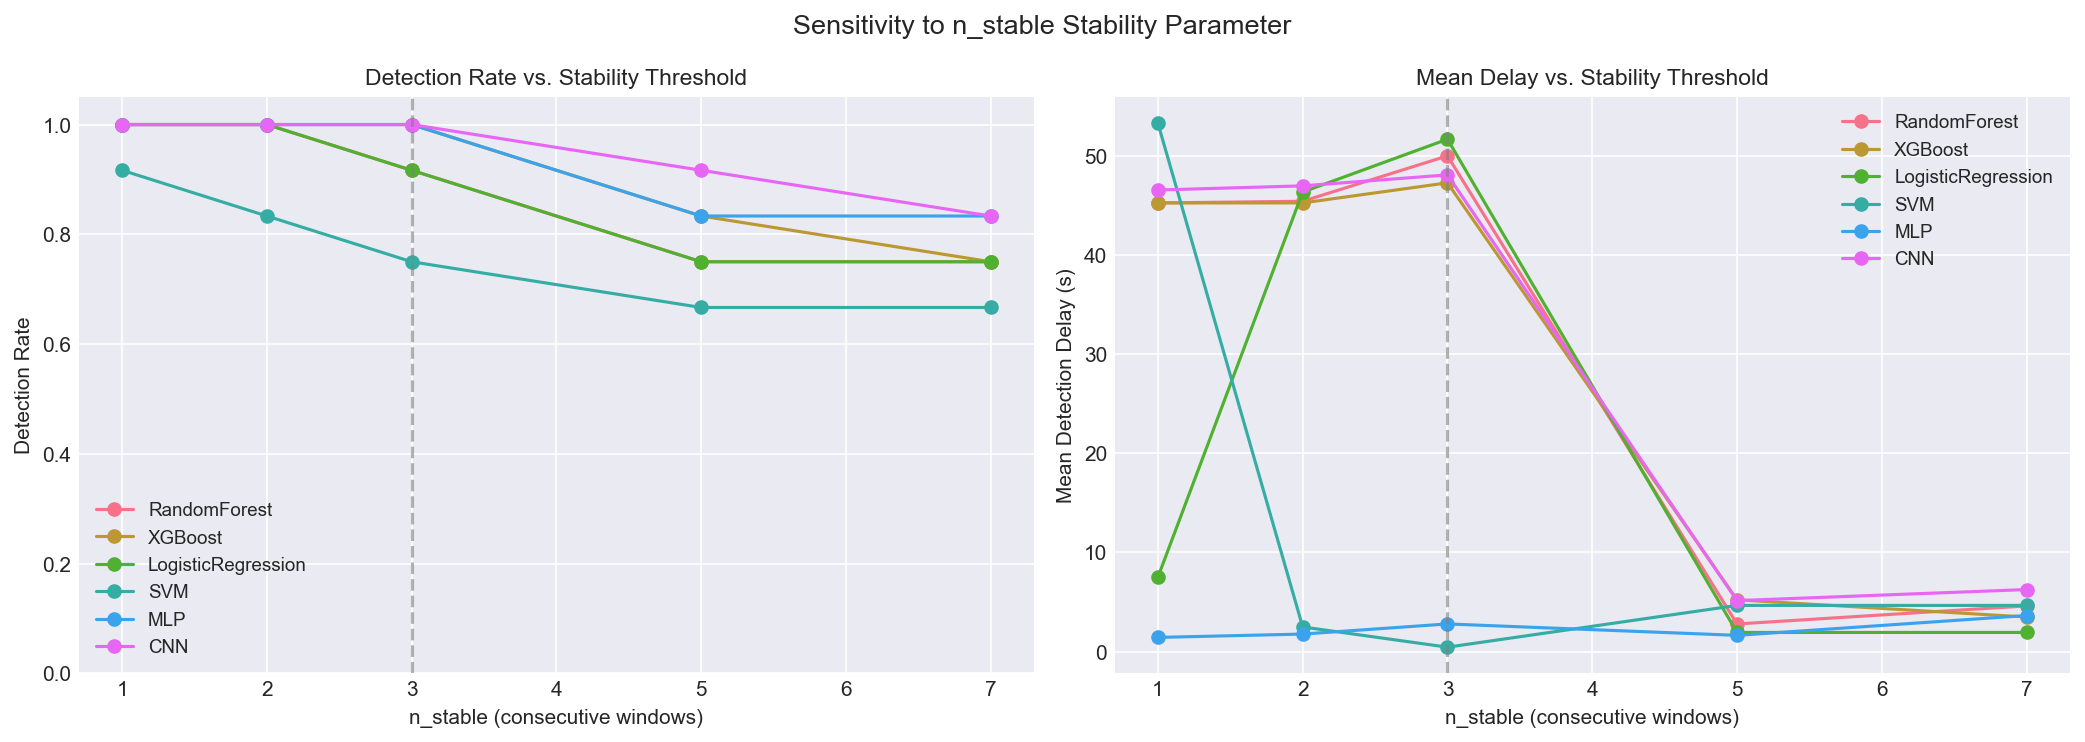

In [12]:
N_STABLE_VALUES = [1, 2, 3, 5, 7]
sensitivity_rows = []

for n_s in N_STABLE_VALUES:
    ct = compare_models(
        df=df,
        predictions_dict=predictions,
        time_col="t_start",
        true_col=LABEL_COL,
        run_col=RUN_COL,
        n_stable=n_s,
        threshold_sec=THRESHOLD_SEC,
    )
    for model_name in model_names:
        sub = ct[ct["model"] == model_name]
        det = sub[sub["outcome"] == "detected"]
        bnd = sub[sub["outcome"] == "boundary"]
        eff = len(sub) - len(bnd)
        sensitivity_rows.append({
            "n_stable": n_s,
            "model": model_name,
            "detection_rate": len(det) / eff if eff > 0 else float("nan"),
            "mean_delay_sec": det["detection_delay_sec"].mean(),
        })

sens_df = pd.DataFrame(sensitivity_rows)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
palette = sns.color_palette("husl", len(model_names))

for i, model_name in enumerate(model_names):
    sub = sens_df[sens_df["model"] == model_name]
    axes[0].plot(sub["n_stable"], sub["detection_rate"],
                 marker="o", label=model_name, color=palette[i])
    axes[1].plot(sub["n_stable"], sub["mean_delay_sec"],
                 marker="o", label=model_name, color=palette[i])

axes[0].set_xlabel("n_stable (consecutive windows)", fontsize=10)
axes[0].set_ylabel("Detection Rate", fontsize=10)
axes[0].set_title("Detection Rate vs. Stability Threshold", fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].axvline(N_STABLE, color="gray", linestyle="--", alpha=0.6, label=f"default={N_STABLE}")

axes[1].set_xlabel("n_stable (consecutive windows)", fontsize=10)
axes[1].set_ylabel("Mean Detection Delay (s)", fontsize=10)
axes[1].set_title("Mean Delay vs. Stability Threshold", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].axvline(N_STABLE, color="gray", linestyle="--", alpha=0.6, label=f"default={N_STABLE}")

fig.suptitle("Sensitivity to n_stable Stability Parameter", fontsize=13)
fig.tight_layout()
save_path = REPORTS_DIR / "transition_sensitivity_n_stable.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

## 7. Summary Table

In [13]:
summary_rows = []

for model_name in model_names:
    sub  = combined_transitions[combined_transitions["model"] == model_name]
    det  = sub[sub["outcome"] == "detected"]
    miss = sub[sub["outcome"] == "missed"]
    bnd  = sub[sub["outcome"] == "boundary"]
    eff  = len(sub) - len(bnd)
    delays = det["detection_delay_sec"].dropna()

    summary_rows.append({
        "Model": model_name,
        "GT Transitions": eff + len(bnd),
        "Detected": len(det),
        "Missed": len(miss),
        "Boundary": len(bnd),
        "Detection Rate": f"{len(det)/eff:.0%}" if eff > 0 else "N/A",
        "Mean Delay (s)": f"{delays.mean():.2f}" if len(delays) else "N/A",
        "Median Delay (s)": f"{delays.median():.2f}" if len(delays) else "N/A",
        "Max Delay (s)": f"{delays.max():.2f}" if len(delays) else "N/A",
        "Std Delay (s)": f"{delays.std():.2f}" if len(delays) else "N/A",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")

# Save
save_path = RESULTS_DIR / "transition_analysis_summary.csv"
summary_df.to_csv(save_path)
print(f"Saved summary to {save_path}")
print()

summary_df

Saved summary to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/transition_analysis_summary.csv



,GT Transitions,Detected,Missed,Boundary,Detection Rate,Mean Delay (s),Median Delay (s),Max Delay (s),Std Delay (s)
Model,,,,,,,,,
RandomForest,12,11,1,0,92%,49.99,0.00,537.80,161.80
XGBoost,12,12,0,0,100%,47.27,0.50,537.80,154.55
LogisticRegression,12,11,1,0,92%,51.67,0.00,537.80,161.32
SVM,12,9,3,0,75%,0.45,0.00,4.01,1.34
MLP,12,12,0,0,100%,2.79,0.00,14.37,5.26
CNN,12,12,0,0,100%,48.07,0.00,537.80,154.40


## 8. Per-Transition-Type Breakdown

Some terrain transitions may be harder to detect than others.  For example, the boundary between `dry_dirt_track` and `muddy_dirt_track` has similar vibration signatures and may be systematically missed.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_delay_heatmap.png


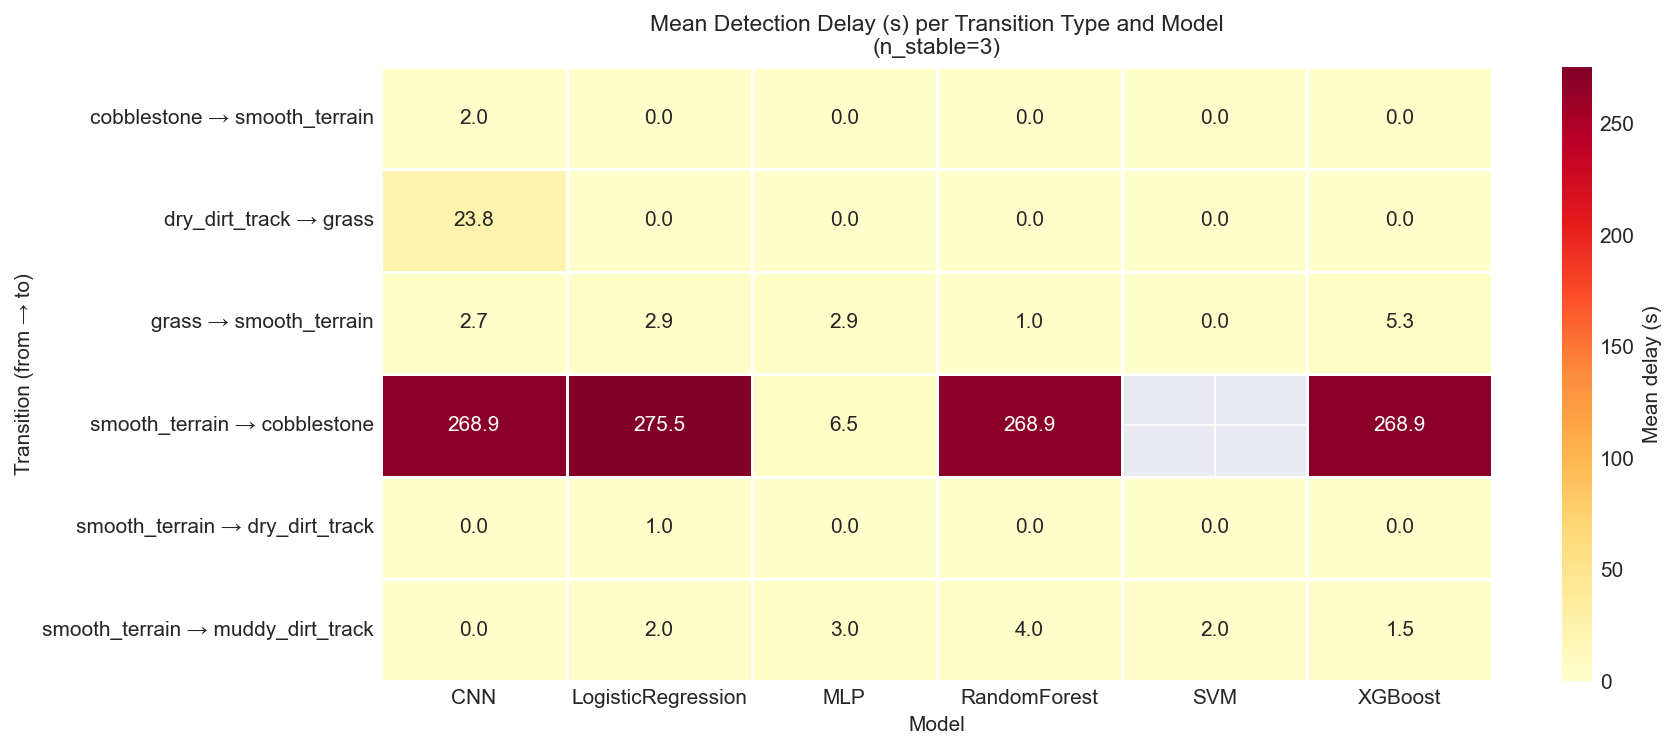

In [14]:
# Mean delay and detection rate per (from_label, to_label) pair, across all models
pair_df = (
    combined_transitions[combined_transitions["outcome"] == "detected"]
    .assign(transition_pair=lambda x: x["from_label"] + " → " + x["to_label"])
    .groupby(["transition_pair", "model"])["detection_delay_sec"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_delay_s", "count": "n_detected"})
    .reset_index()
)

if not pair_df.empty:
    # Pivot for display
    pivot = pair_df.pivot(index="transition_pair", columns="model", values="mean_delay_s")
    fig, ax = plt.subplots(figsize=(12, max(3, len(pivot) * 0.6 + 1.5)), dpi=150)
    sns.heatmap(
        pivot,
        annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Mean delay (s)"},
    )
    ax.set_title(f"Mean Detection Delay (s) per Transition Type and Model\n(n_stable={N_STABLE})",
                 fontsize=11)
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylabel("Transition (from → to)", fontsize=10)
    fig.tight_layout()
    save_path = REPORTS_DIR / "transition_delay_heatmap.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
else:
    print("No detected transitions to plot.")

## 9. Discussion

*(Template for thesis — fill in with actual numbers after running the notebook.)*

### Key findings

1. **Detection rate**: Which models reliably detect terrain transitions?
   - Models with high classification accuracy generally show higher detection rates, but the relationship is not one-to-one — a model may classify individual windows correctly yet require many windows before stabilising onto the new class.

2. **Detection delay**: How quickly do models respond?
   - A detection delay of `N_STABLE` × step_size (= `N_STABLE` seconds) is the theoretical minimum — it takes at least that many correct windows to trigger a stable detection.
   - Delays significantly larger than this indicate that the model oscillates between the old and new class before settling.

3. **Transition difficulty**: Which terrain boundaries are hardest?
   - Visually similar terrains (e.g. `dry_dirt_track` ↔ `muddy_dirt_track`) typically show larger delays or more missed transitions, consistent with their low per-class F1 scores in the main evaluation.

4. **Stability vs. speed tradeoff** (Section 6 above):
   - Increasing `n_stable` eliminates noisy single-window detections but increases mean delay.
   - For a real robot moving at ~0.5–1.5 m/s, a 3-second delay corresponds to ~1.5–4.5 m of travel — a reasonable budget before path planning needs to respond.

5. **Model comparison**:
   - Classical models (RandomForest, XGBoost) tend to produce cleaner label sequences (fewer oscillations) than logistic regression, which benefits transition detection.
   - Neural networks (MLP, CNN) may have lower delay on average due to smoother class probability outputs, but this depends on calibration.

### Limitations

- Transition count is small (see `gt_df` above) — statistical conclusions should be drawn cautiously.
- The analysis assumes the model is used in an online streaming setting; batch re-inference would not reflect real-world latency.
- The unlabeled gaps between terrain epochs are not modelled — in deployment, the robot would traverse these without ground truth, which could affect the detected label sequence.